N-XGB implementation without using SMOTE

Test Accuracy (Without SMOTE): 0.8391356542617047

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.65      0.67       150
           1       0.88      0.93      0.90       646
           2       0.11      0.03      0.04        37

    accuracy                           0.84       833
   macro avg       0.56      0.54      0.54       833
weighted avg       0.81      0.84      0.82       833



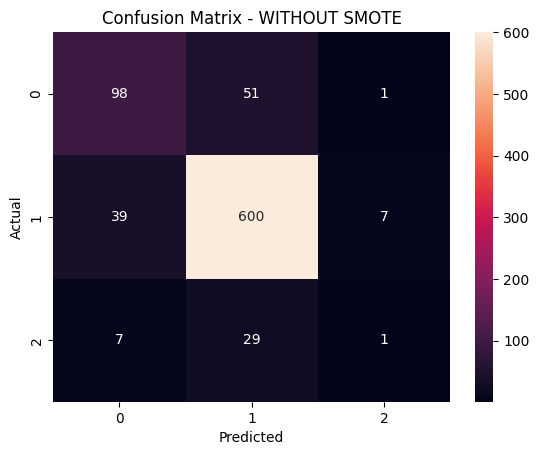

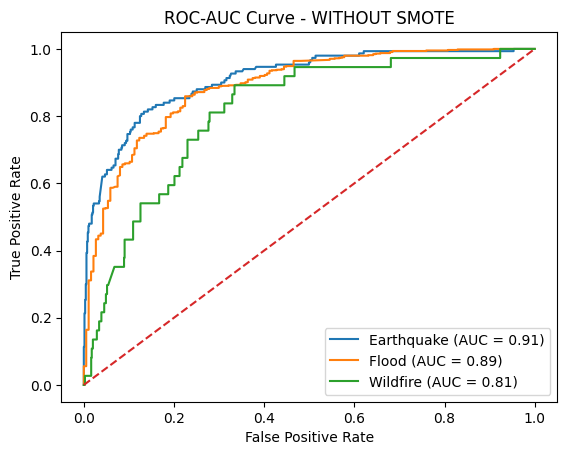

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

df = pd.read_excel("EM-DAT_dataset.xlsx")
target_column = "Disaster Type"

df = df[df[target_column].isin(["Wildfire", "Flood", "Earthquake"])].copy()

X = df.drop(columns=[target_column])
y = df[target_column]

# Preprocessing

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Neural Feature Extraction

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))


class NeuralFeatureModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.classifier(features)
        return output


model = NeuralFeatureModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()


model.eval()
with torch.no_grad():
    H_train = model.feature_extractor(X_train_tensor).numpy()
    H_test = model.feature_extractor(X_test_tensor).numpy()


# XGBoost Training

xgb_model = XGBClassifier(
    learning_rate=0.05,
    max_depth=7,
    n_estimators=300,
    subsample=1.0,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(H_train, y_train)

y_pred = xgb_model.predict(H_test)


# Evaluation

print("Test Accuracy (Without SMOTE):",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - WITHOUT SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Get probability predictions
y_prob = xgb_model.predict_proba(H_test)

# Binarize the test labels
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Plot ROC Curve
plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{target_encoder.classes_[i]} (AUC = {roc_auc:.2f})"
    )

# Random guess line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - WITHOUT SMOTE")
plt.legend()
plt.show()
